# DNU 70/2017 — Período de derogación: 1 al 15 de marzo de 2021

Subconjunto del dataset `piubamas_dnu_v2` que abarca los **15 días** en torno  
a la derogación del DNU 70/2017 (decreto de Macri sobre migraciones),  
firmada el **5 de marzo de 2021** por el gobierno de Alberto Fernández.

**Contenido**
1. Carga, filtrado y guardado del dataset
2. Estadísticas generales y distribución de etiquetas
3. Actividad por diario
4. Serie temporal diaria — odio y racismo
5. Ejemplos de tweets — notas clave del período


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import html as htmllib
from IPython.display import display, HTML

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['font.size'] = 11

LABELS = ['CALLS', 'WOMEN', 'LGBTI', 'RACISM', 'CLASS', 'POLITICS', 'DISABLED', 'APPEARANCE', 'CRIMINAL']

NOMBRES = {
    'clarincom': 'Clarín', 'LANACION': 'La Nación', 'infobae': 'Infobae',
    'pagina12': 'Página 12', 'cronica': 'Crónica', 'perfilcom': 'Perfil',
    'laderechamedios': 'La Derecha Medios', 'laderechadiario': 'La Derecha Diario',
    'izquierdadiario': 'Izquierda Diario',
}

CATEGORIAS = {
    'RACISM':     ('#c0392b', 'Xenofobia/Racismo'),
    'CALLS':      ('#922b21', 'Llamado a violencia'),
    'WOMEN':      ('#884ea0', 'Odio a mujeres'),
    'LGBTI':      ('#1a5276', 'Odio LGBTI+'),
    'CLASS':      ('#1e8449', 'Clase social'),
    'POLITICS':   ('#d4ac0d', 'Odio político'),
    'DISABLED':   ('#2471a3', 'Discapacidad'),
    'APPEARANCE': ('#ca6f1e', 'Apariencia'),
    'CRIMINAL':   ('#5d6d7e', 'Estigma criminal'),
}


## 1. Carga y filtrado del dataset

In [2]:
dnu_full = pd.read_csv('data/piubamas_dnu_v2.csv', parse_dates=['date_tweet'])

FECHA_INICIO = '2021-03-01'
FECHA_FIN    = '2021-03-15'

mask = (
    (dnu_full['date_tweet'].dt.date >= pd.Timestamp(FECHA_INICIO).date()) &
    (dnu_full['date_tweet'].dt.date <= pd.Timestamp(FECHA_FIN).date())
)
df = dnu_full[mask].copy().reset_index(drop=True)
df['n_labels'] = df[LABELS].sum(axis=1)

print(f'Dataset DNU completo : {len(dnu_full):>10,} comentarios')
print(f'Período filtrado     : {len(df):>10,} comentarios  ({FECHA_INICIO} a {FECHA_FIN})')
print(f'Noticias únicas      : {df["tweet_id_noticia"].nunique():>10,}')
print(f'Medios cubiertos     : {df["medio"].nunique():>10,}')
df.head(3)


Dataset DNU completo :  1,056,507 comentarios
Período filtrado     :     15,974 comentarios  (2021-03-01 a 2021-03-15)
Noticias únicas      :      2,033
Medios cubiertos     :          8


,id,tweet_id_noticia,title,resumen,medio,date_tweet,text,user_id,HATEFUL,CALLS,WOMEN,LGBTI,RACISM,CLASS,POLITICS,DISABLED,APPEARANCE,CRIMINAL,n_labels
0,219,1234890909105446912,NaN,🔴 AHORA | Confirmaron el primer caso de corona...,infobae,2021-03-03 03:12:02,@infobae Ode monios,1170690129264087042,0,0,0,0,0,0,0,0,0,0,0
1,220,1234890909105446912,NaN,🔴 AHORA | Confirmaron el primer caso de corona...,infobae,2021-03-03 03:12:03,@infobae No me la container,771775249729875968,0,0,0,0,0,0,0,0,0,0,0
2,221,1234890909105446912,NaN,🔴 AHORA | Confirmaron el primer caso de corona...,infobae,2021-03-03 03:16:00,@infobae No me la coutinho,1238998277896486912,0,0,0,0,0,0,0,0,0,0,0


In [3]:
OUT_PATH = 'data/piubamas_dnu_marzo2021.csv'
df.to_csv(OUT_PATH, index=False)
print(f'Guardado: {OUT_PATH}  ({len(df):,} filas x {df.shape[1]} columnas)')


Guardado: data/piubamas_dnu_marzo2021.csv  (15,974 filas x 19 columnas)


## 2. Estadísticas generales

In [4]:
print('=' * 55)
print('ESTADÍSTICAS — 1 al 15 de marzo de 2021')
print('=' * 55)
print(f'  Total comentarios  : {len(df):>10,}')
print(f'  Comentarios odiosos: {df["HATEFUL"].sum():>10,}  ({df["HATEFUL"].mean()*100:.1f}%)')
print(f'  No odiosos         : {(df["HATEFUL"]==0).sum():>10,}  ({(df["HATEFUL"]==0).mean()*100:.1f}%)')
print(f'  Medios cubiertos   : {df["medio"].nunique():>10,}')
print(f'  Noticias únicas    : {df["tweet_id_noticia"].nunique():>10,}')
print()

counts = df[LABELS].sum().sort_values(ascending=False)
pcts   = (counts / len(df) * 100).round(1)
tabla  = pd.DataFrame({'tweets': counts.astype(int), '% del total': pcts})
tabla.index.name = 'etiqueta'

con_hs = (df['n_labels'] > 0).sum()
sin_hs = (df['n_labels'] == 0).sum()
print(f'Con al menos una etiqueta : {con_hs:,}  ({con_hs/len(df)*100:.1f}%)')
print(f'Sin ninguna etiqueta      : {sin_hs:,}  ({sin_hs/len(df)*100:.1f}%)')
print()

display(
    tabla.style
    .format({'tweets': '{:,}', '% del total': '{:.1f}%'})
    .background_gradient(subset=['tweets'], cmap='Reds')
    .set_caption('Tweets por categoría de discurso de odio — 1 al 15 de marzo 2021')
    .set_table_styles([{
        'selector': 'caption',
        'props': [('font-size', '13px'), ('font-weight', 'bold'), ('text-align', 'left')]
    }])
)


ESTADÍSTICAS — 1 al 15 de marzo de 2021
  Total comentarios  :     15,974
  Comentarios odiosos:        685  (4.3%)
  No odiosos         :     15,289  (95.7%)
  Medios cubiertos   :          8
  Noticias únicas    :      2,033

Con al menos una etiqueta : 685  (4.3%)
Sin ninguna etiqueta      : 15,289  (95.7%)



,tweets,% del total
etiqueta,,
POLITICS,245,1.5%
RACISM,214,1.3%
APPEARANCE,154,1.0%
DISABLED,61,0.4%
WOMEN,48,0.3%
CALLS,39,0.2%
CLASS,35,0.2%
LGBTI,24,0.2%
CRIMINAL,15,0.1%


## 3. Actividad por diario

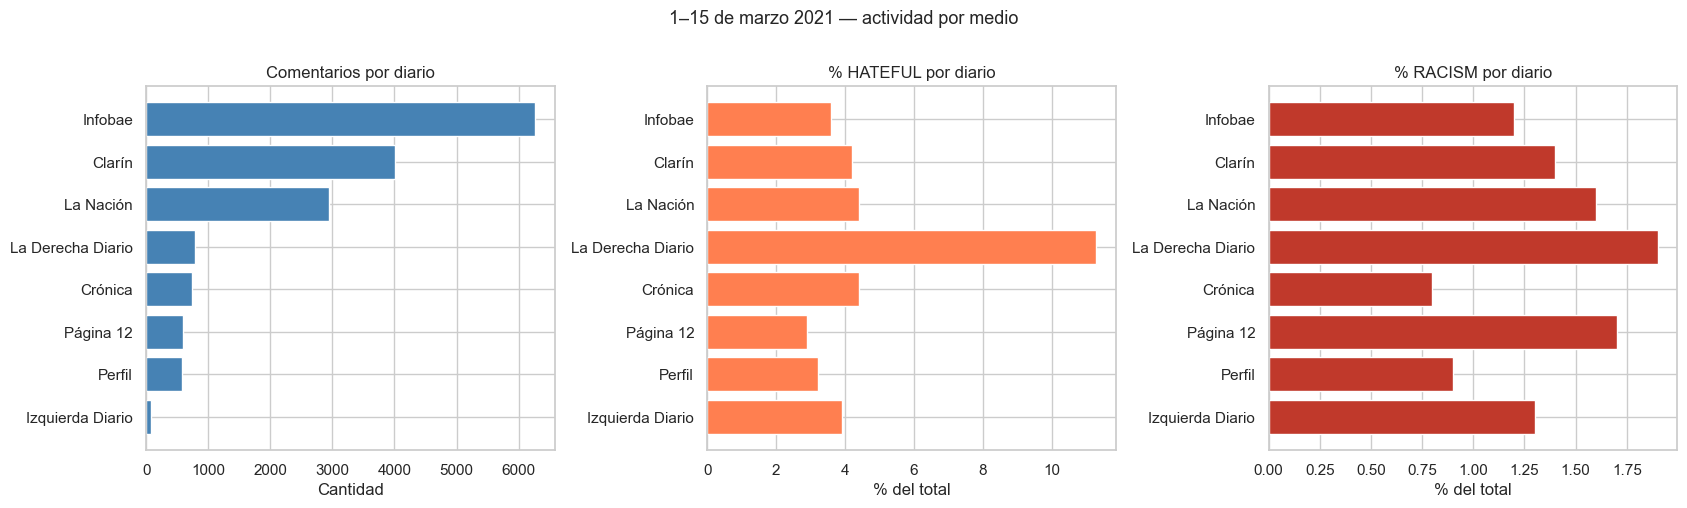

,noticias,comentarios,odiosos,% odio,racism,% racism
medio,,,,,,
Infobae,691,6267,228,3.6,75,1.2
Clarín,434,4005,167,4.2,56,1.4
La Nación,311,2940,130,4.4,46,1.6
La Derecha Diario,63,793,90,11.3,15,1.9
Crónica,177,733,32,4.4,6,0.8
Página 12,169,588,17,2.9,10,1.7
Perfil,146,571,18,3.2,5,0.9
Izquierda Diario,42,77,3,3.9,1,1.3


In [5]:
medios_stats = df.groupby('medio').agg(
    comentarios=('text', 'count'),
    noticias=('tweet_id_noticia', 'nunique'),
    odiosos=('HATEFUL', 'sum'),
    racism=('RACISM', 'sum'),
).sort_values('comentarios', ascending=False)
medios_stats['pct_odio']   = (medios_stats['odiosos'] / medios_stats['comentarios'] * 100).round(1)
medios_stats['pct_racism'] = (medios_stats['racism']  / medios_stats['comentarios'] * 100).round(1)

nombres = [NOMBRES.get(m, m) for m in medios_stats.index]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
axes[0].barh(nombres[::-1], medios_stats['comentarios'].values[::-1], color='steelblue')
axes[0].set_title('Comentarios por diario')
axes[0].set_xlabel('Cantidad')
axes[1].barh(nombres[::-1], medios_stats['pct_odio'].values[::-1], color='coral')
axes[1].set_title('% HATEFUL por diario')
axes[1].set_xlabel('% del total')
axes[2].barh(nombres[::-1], medios_stats['pct_racism'].values[::-1], color='#c0392b')
axes[2].set_title('% RACISM por diario')
axes[2].set_xlabel('% del total')
fig.suptitle('1–15 de marzo 2021 — actividad por medio', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('outputs/dnu_marzo2021_medios.png', dpi=150, bbox_inches='tight')
plt.show()

display(
    medios_stats
    .rename(index=NOMBRES)
    .rename(columns={'pct_odio': '% odio', 'pct_racism': '% racism'})
    [['noticias', 'comentarios', 'odiosos', '% odio', 'racism', '% racism']]
)


## 4. Serie temporal diaria — odio y racismo

El período analizado es de solo **15 días**, por lo que se usa frecuencia **diaria**.  
La línea vertical punteada marca el **5 de marzo de 2021**, día de la derogación del DNU 70/2017.


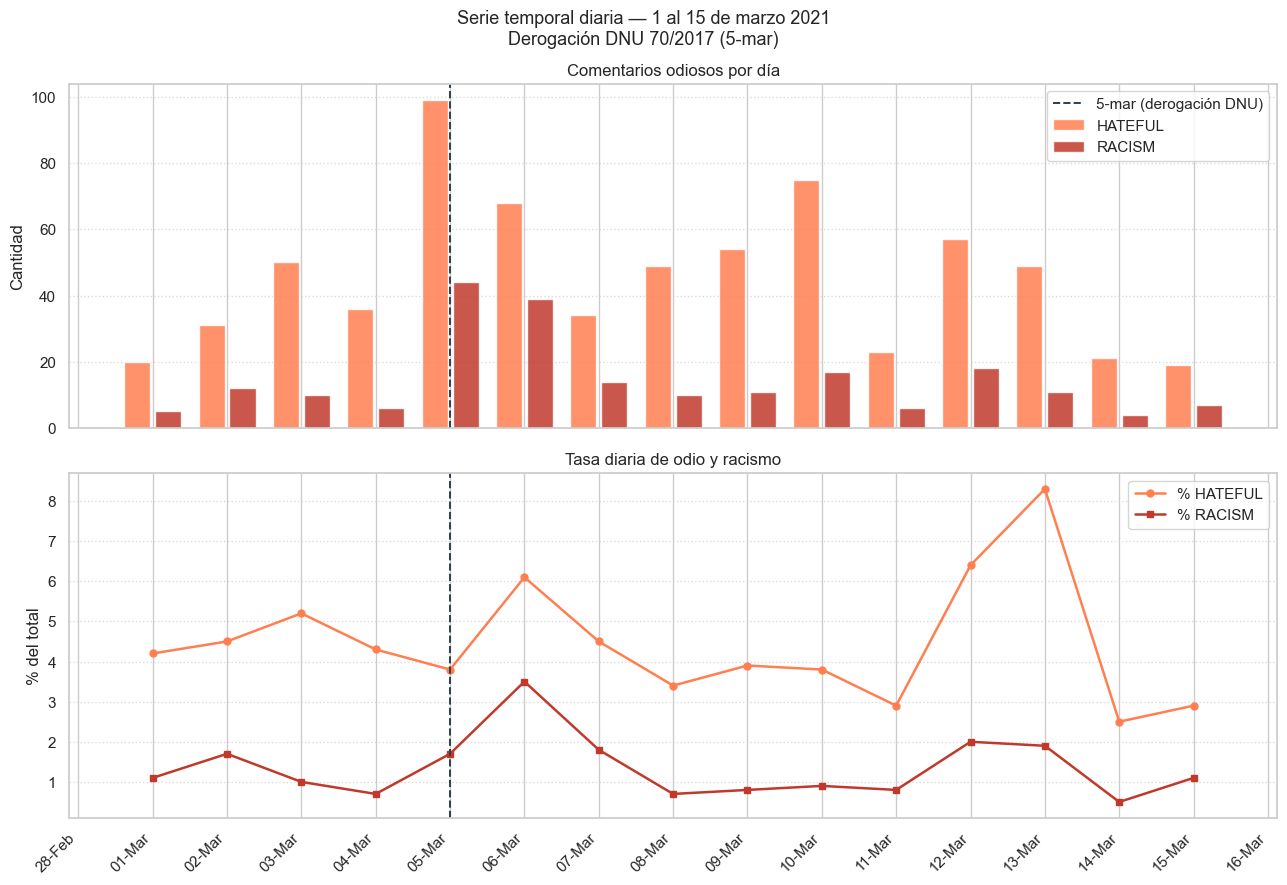

Resumen diario:


,total,HATEFUL,RACISM,% HATEFUL,% RACISM
date_tweet,,,,,
2021-03-01,476,20,5,4.2,1.1
2021-03-02,694,31,12,4.5,1.7
2021-03-03,955,50,10,5.2,1.0
2021-03-04,831,36,6,4.3,0.7
2021-03-05,2606,99,44,3.8,1.7
2021-03-06,1123,68,39,6.1,3.5
2021-03-07,764,34,14,4.5,1.8
2021-03-08,1436,49,10,3.4,0.7
2021-03-09,1375,54,11,3.9,0.8


In [6]:
ts = (
    df.set_index('date_tweet')
    .resample('D')
    .agg(
        n=('HATEFUL', 'count'),
        n_hateful=('HATEFUL', 'sum'),
        n_racism=('RACISM', 'sum'),
    )
)
ts['pct_hateful'] = (ts['n_hateful'] / ts['n'] * 100).round(1)
ts['pct_racism']  = (ts['n_racism']  / ts['n'] * 100).round(1)

DERO = pd.Timestamp('2021-03-05')

fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

# Panel superior: cantidades absolutas
ax = axes[0]
x  = ts.index
ax.bar([d - pd.Timedelta(hours=5) for d in x], ts['n_hateful'],
       width=0.35, color='coral', alpha=0.85, label='HATEFUL')
ax.bar([d + pd.Timedelta(hours=5) for d in x], ts['n_racism'],
       width=0.35, color='#c0392b', alpha=0.85, label='RACISM')
ax.axvline(DERO, color='#2c3e50', linestyle='--', linewidth=1.4,
           label='5-mar (derogación DNU)')
ax.set_title('Comentarios odiosos por día')
ax.set_ylabel('Cantidad')
ax.legend()
ax.yaxis.grid(True, linestyle=':', alpha=0.7)

# Panel inferior: tasas
ax2 = axes[1]
ax2.plot(x, ts['pct_hateful'], color='coral', marker='o',
         linewidth=1.8, markersize=5, label='% HATEFUL')
ax2.plot(x, ts['pct_racism'], color='#c0392b', marker='s',
         linewidth=1.8, markersize=5, label='% RACISM')
ax2.axvline(DERO, color='#2c3e50', linestyle='--', linewidth=1.4)
ax2.set_title('Tasa diaria de odio y racismo')
ax2.set_ylabel('% del total')
ax2.legend()
ax2.yaxis.grid(True, linestyle=':', alpha=0.7)

axes[1].xaxis.set_major_locator(mdates.DayLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')

fig.suptitle('Serie temporal diaria — 1 al 15 de marzo 2021\nDerogación DNU 70/2017 (5-mar)', fontsize=13)
plt.tight_layout()
plt.savefig('outputs/dnu_marzo2021_serie_diaria.png', dpi=150, bbox_inches='tight')
plt.show()

print('Resumen diario:')
display(ts.rename(columns={'n': 'total', 'n_hateful': 'HATEFUL', 'n_racism': 'RACISM',
                           'pct_hateful': '% HATEFUL', 'pct_racism': '% RACISM'}))


## 5. Ejemplos de tweets

Se muestran las notas con mayor cantidad de comentarios odiosos en los días clave del período.


In [12]:
def make_badges(c_row):
    badges = ''.join(
        f'<span style="background:{color};color:white;padding:2px 7px;border-radius:10px;'
        f'font-size:11px;margin-right:3px;">{label}</span>'
        for col, (color, label) in CATEGORIAS.items() if c_row.get(col, 0) == 1
    )
    return badges or '<span style="color:#aaa;font-size:11px;">sin etiqueta</span>'


def render_nota(row, source_df, n_comentarios=5, seed=42):
    tweet_id     = row['tweet_id_noticia']
    medio        = row['medio']
    nombre_medio = NOMBRES.get(medio, medio)
    titulo       = htmllib.escape(str(row['title']))
    resumen      = htmllib.escape(str(row['resumen'])[:280])
    n_total      = int(row['n_total'])
    n_odio       = int(row['n_odio'])
    pct          = round(n_odio / n_total * 100, 1) if n_total > 0 else 0
    todos        = source_df[source_df['tweet_id_noticia'] == tweet_id]
    fecha_str    = todos['date_tweet'].min().strftime('%d %b %Y')
    url_tweet    = f'https://twitter.com/{medio}/status/{tweet_id}'

    pool    = todos[todos['HATEFUL'] == 1]
    if len(pool) == 0:
        pool = todos
    muestra = pool.sample(min(n_comentarios, len(pool)), random_state=seed)

    comentarios_html = ''
    for idx, (_, c) in enumerate(muestra.iterrows(), 1):
        texto   = htmllib.escape(str(c['text'])[:300])
        fecha_c = c['date_tweet'].strftime('%d %b %Y %H:%M')
        comentarios_html += (
            f'<div style="margin:8px 0 8px 32px;padding:10px 14px;background:#fff;'
            f'border-left:3px solid #e74c3c;border-radius:6px;'
            f'box-shadow:0 1px 3px rgba(0,0,0,0.07);">'
            f'<div style="font-size:11px;color:#999;margin-bottom:5px;">#{idx} &middot; {fecha_c}</div>'
            f'<div style="font-size:13px;color:#222;line-height:1.55;">{texto}</div>'
            f'<div style="margin-top:6px;">{make_badges(c)}</div>'
            f'</div>'
        )

    return (
        f'<div style="margin-bottom:28px;">'
        f'<div style="background:#f7f9fa;border:1px solid #dce1e7;border-radius:12px;padding:16px 18px;">'
        f'<div style="display:flex;align-items:center;margin-bottom:10px;">'
        f'<div style="width:38px;height:38px;background:#1da1f2;border-radius:50%;'
        f'display:flex;align-items:center;justify-content:center;'
        f'color:white;font-weight:bold;font-size:16px;margin-right:10px;flex-shrink:0;">{nombre_medio[0]}</div>'
        f'<div>'
        f'<div style="font-weight:700;font-size:13px;color:#14171a;">{nombre_medio}</div>'
        f'<div style="font-size:11px;color:#657786;">@{medio} &middot; {fecha_str}</div>'
        f'</div>'
        f'<div style="margin-left:auto;display:flex;gap:6px;">'
        f'<span style="background:#e74c3c;color:white;font-size:11px;padding:3px 8px;border-radius:10px;">'
        f'{pct}% odio ({n_odio}/{n_total})</span>'
        f'<span style="background:#1da1f2;color:white;font-size:11px;padding:3px 8px;border-radius:10px;">NOTICIA</span>'
        f'</div></div>'
        f'<div style="font-size:14px;font-weight:600;color:#14171a;line-height:1.4;margin-bottom:8px;">{titulo}</div>'
        f'<div style="font-size:13px;color:#555;line-height:1.55;margin-bottom:10px;">{resumen}</div>'
        f'<a href="{url_tweet}" target="_blank" style="color:#1da1f2;font-size:12px;">Ver tweet original</a>'
        f'</div>'
        f'<div style="margin:6px 0 0 8px;color:#aaa;font-size:11px;">'
        f'Muestra de {len(muestra)} comentarios odiosos (de {n_odio} totales)</div>'
        f'{comentarios_html}'
        f'</div>'
    )


def top_notas(source_df, n=3, label='HATEFUL'):
    return (
        source_df
        .groupby(['tweet_id_noticia', 'medio', 'title', 'resumen'])
        .agg(n_total=('text', 'count'), n_odio=(label, 'sum'))
        .reset_index()
        .sort_values('n_odio', ascending=False)
        .head(n)
        .reset_index(drop=True)
    )


### 5.1 Notas más odiosas del 5 de marzo de 2021 (derogación del DNU)

El **5 de marzo de 2021** el gobierno de Alberto Fernández derogó el DNU 70/2017 de Macri,
que restringía el ingreso al país de ciudadanos extranjeros con antecedentes penales.


In [8]:
FECHA_DERO = '2021-03-05'

df_dero = df[df['date_tweet'].dt.date == pd.Timestamp(FECHA_DERO).date()].copy()
print(f'{FECHA_DERO} — {len(df_dero):,} comentarios | '
      f'HATEFUL: {df_dero["HATEFUL"].sum():,} ({df_dero["HATEFUL"].mean()*100:.1f}%) | '
      f'RACISM: {df_dero["RACISM"].sum():,} ({df_dero["RACISM"].mean()*100:.1f}%)')

notas_dero = top_notas(df_dero, n=3)
display(notas_dero[['medio', 'n_total', 'n_odio', 'title']])

bloques = ''.join(render_nota(row, df_dero, n_comentarios=5, seed=42)
                  for _, row in notas_dero.iterrows())
display(HTML(
    f'<div style="font-family:Segoe UI,Arial,sans-serif;max-width:720px;margin:20px auto;">'
    f'<div style="background:#fdf2f2;border-left:4px solid #c0392b;border-radius:6px;'
    f'padding:10px 16px;margin-bottom:20px;font-size:13px;color:#c0392b;">'
    f'<strong>5 de marzo de 2021</strong> — Derogación DNU 70/2017 '
    f'({len(df_dero):,} comentarios, {df_dero["HATEFUL"].mean()*100:.1f}% odiosos)'
    f'</div>'
    f'{bloques}'
    f'</div>'
))


2021-03-05 — 2,606 comentarios | HATEFUL: 99 (3.8%) | RACISM: 44 (1.7%)


,medio,n_total,n_odio,title
0,infobae,609,27,El Gobierno derogó el decreto de Macri que imp...
1,clarincom,710,23,El Gobierno derogó el decreto de Mauricio Macr...
2,LANACION,137,11,Ley de Migraciones: el Gobierno derogó el decr...


### 5.2 Día con mayor tasa de odio en el período (detección automática)

In [9]:
ts_diario = (
    df.set_index('date_tweet')
    .resample('D')['HATEFUL']
    .agg(hate_rate='mean', n='count')
)
ts_diario = ts_diario[ts_diario['n'] >= 20]
dia_pico  = ts_diario['hate_rate'].idxmax().date()
hate_pct  = ts_diario['hate_rate'].max() * 100
print(f'Día pico HATEFUL: {dia_pico} | tasa: {hate_pct:.1f}%')

df_pico    = df[df['date_tweet'].dt.date == dia_pico].copy()
notas_pico = top_notas(df_pico, n=3)
display(notas_pico[['medio', 'n_total', 'n_odio', 'title']])

bloques = ''.join(render_nota(row, df_pico, n_comentarios=5, seed=42)
                  for _, row in notas_pico.iterrows())
display(HTML(
    f'<div style="font-family:Segoe UI,Arial,sans-serif;max-width:720px;margin:20px auto;">'
    f'<div style="background:#fdf2f2;border-left:4px solid #c0392b;border-radius:6px;'
    f'padding:10px 16px;margin-bottom:20px;font-size:13px;color:#c0392b;">'
    f'<strong>Día pico: {dia_pico}</strong> — tasa de odio: {hate_pct:.1f}%'
    f'</div>'
    f'{bloques}'
    f'</div>'
))


Día pico HATEFUL: 2021-03-13 | tasa: 8.3%


,medio,n_total,n_odio,title
0,LANACION,6,2,Gerardo Rozín: “La pandemia hizo muy difícil g...
1,LANACION,2,1,Coronavirus: restringen vuelos de Estados Unid...
2,clarincom,23,1,Tras un viaje de egresados a Cancún con 44 pos...


### 5.3 Día con mayor tasa de RACISM en el período

In [10]:
ts_racism_d = (
    df.set_index('date_tweet')
    .resample('D')['RACISM']
    .agg(racism_rate='mean', n='count')
)
ts_racism_d = ts_racism_d[ts_racism_d['n'] >= 20]
dia_pico_r  = ts_racism_d['racism_rate'].idxmax().date()
racism_pct  = ts_racism_d['racism_rate'].max() * 100
print(f'Día pico RACISM: {dia_pico_r} | tasa: {racism_pct:.1f}%')

df_pico_r    = df[df['date_tweet'].dt.date == dia_pico_r].copy()
notas_pico_r = top_notas(df_pico_r, n=3, label='RACISM')
display(notas_pico_r[['medio', 'n_total', 'n_odio', 'title']])

bloques = ''.join(render_nota(row, df_pico_r, n_comentarios=5, seed=42)
                  for _, row in notas_pico_r.iterrows())
display(HTML(
    f'<div style="font-family:Segoe UI,Arial,sans-serif;max-width:720px;margin:20px auto;">'
    f'<div style="background:#fdf2f2;border-left:4px solid #c0392b;border-radius:6px;'
    f'padding:10px 16px;margin-bottom:20px;font-size:13px;color:#c0392b;">'
    f'<strong>Día pico RACISM: {dia_pico_r}</strong> — tasa: {racism_pct:.1f}%'
    f'</div>'
    f'{bloques}'
    f'</div>'
))


Día pico RACISM: 2021-03-06 | tasa: 3.5%


,medio,n_total,n_odio,title
0,infobae,108,6,Y si canto de este modo
1,LANACION,9,5,Migraciones. “¿A quién se le ocurre que querem...
2,pagina12,30,4,El Gobierno derogó el decreto migratorio del m...


## 6. Exportar notebook a HTML

In [11]:
import nbformat
from nbconvert import HTMLExporter
from datetime import date

nb_path  = '3_DNU_marzo2021.ipynb'
out_path = f'outputs/3_DNU_marzo2021_{date.today()}.html'

with open(nb_path, encoding='utf-8') as f:
    nb_node = nbformat.read(f, as_version=4)

body, _ = HTMLExporter().from_notebook_node(nb_node)

with open(out_path, 'w', encoding='utf-8') as f:
    f.write(body)

print(f'Guardado: {out_path} ({len(body)//1024} KB)')


Guardado: outputs/3_DNU_marzo2021_2026-04-09.html (359 KB)
